# <font face="Inter, Segoe UI, Arial, sans-serif" color="#38BDF8"><b>Dataset Cleaning and Transformation</b></font>

### <font face="Inter, Segoe UI, Arial, sans-serif" color="#A78BFA"><b>Label Decoding • Missing Data Assessment • Duplicate Identification</b></font>

<font face="Inter, Segoe UI, Arial, sans-serif" color="#E2E8F0">
This notebook strengthened our skills in data preprocessing, particularly in decoding categorical labels, assessing missing data, and identifying duplicates. These steps are essential in ensuring data quality, consistency, and reliability before performing any form of analysis or visualization.
</font>

---

#### <font face="Inter, Segoe UI, Arial, sans-serif" color="#FACC15"><b>👥 Executed by:</b> Balictar, Biñas, Soleño</font>

---

### <font face="Inter, Segoe UI, Arial, sans-serif" color="#22D3EE"><b>🏷️ Source of Label Equivalents</b></font>

<font face="Inter, Segoe UI, Arial, sans-serif" color="#E2E8F0">
The numerical values in this dataset were decoded using the official variable descriptions provided by the <b style="color:#38BDF8;">UCI Machine Learning Repository</b> for the dataset <i>“Predict Students' Dropout and Academic Success.”</i> These mappings ensured that numeric codes were accurately translated into meaningful categorical labels, improving interpretability and supporting reliable analysis.
</font>

<br>
<br>

<font face="Inter, Segoe UI, Arial, sans-serif" color="#CBD5F5">
<b style="color:#F472B6;">Dataset Source:</b> Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). <i>Predict Students' Dropout and Academic Success</i> [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
</font>

____

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load your dataset
df = pd.read_csv("data.csv", sep=";")

In [4]:
# Clean column names
df.columns = df.columns.str.strip().str.replace('"', '')

# Rename typo/awkward columns
df.rename(columns={
    "Nacionality": "Nationality",
    "Daytime/evening attendance\t": "Attendance"
}, inplace=True)

# Mapping dictionaries
target_map = {
    0: "Dropout",
    1: "Enrolled",
    2: "Graduate",
    "Dropout": "Dropout",
    "Enrolled": "Enrolled",
    "Graduate": "Graduate"
}

gender_map = {
    0: "Female",
    1: "Male"
}

marital_map = {
    1: "Single",
    2: "Married",
    3: "Widower",
    4: "Divorced",
    5: "Facto Union",
    6: "Legally Separated"
}

attendance_map = {
    0: "Evening",
    1: "Daytime"
}

yes_no_map = {
    0: "No",
    1: "Yes"
}

course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (Evening Attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (Evening Attendance)"
}

application_map = {
    1: "1st Phase — General Contingent",
    2: "Ordinance No. 612/93",
    5: "1st Phase — Special Contingent (Azores Island)",
    7: "Holders of Other Higher Courses",
    10: "Ordinance No. 854-B/99",
    15: "International Student (Bachelor)",
    16: "1st Phase — Special Contingent (Madeira Island)",
    17: "2nd Phase — General Contingent",
    18: "3rd Phase — General Contingent",
    26: "Ordinance No. 533-A/99, Item b2 (Different Plan)",
    27: "Ordinance No. 533-A/99, Item b3 (Other Institution)",
    39: "Over 23 Years Old",
    42: "Transfer",
    43: "Change of Course",
    44: "Technological Specialization Diploma Holders",
    51: "Change of Institution/Course",
    53: "Short Cycle Diploma Holders",
    57: "Change of Institution/Course (International)"
}

previous_qualification_map = {
    1: "Secondary Education",
    2: "Higher Education — Bachelor's Degree",
    3: "Higher Education — Degree",
    4: "Higher Education — Master's",
    5: "Higher Education — Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year — Not Completed",
    10: "11th Year — Not Completed",
    12: "Other — 11th Year",
    14: "10th Year",
    15: "10th Year — Not Completed",
    19: "Basic Education 3rd Cycle",
    38: "Basic Education 2nd Cycle",
    39: "Technological Specialization Course",
    40: "Higher Education — Degree (1st Cycle)",
    42: "Professional Higher Technical Course",
    43: "Higher Education — Master (2nd Cycle)"
}

parent_qualification_map = {
    1: "Secondary Education — 12th Year or Equivalent",
    2: "Higher Education — Bachelor's Degree",
    3: "Higher Education — Degree",
    4: "Higher Education — Master's",
    5: "Higher Education — Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year — Not Completed",
    10: "11th Year — Not Completed",
    11: "7th Year (Old)",
    12: "Other — 11th Year",
    14: "10th Year",
    18: "General Commerce Course",
    19: "Basic Education 3rd Cycle",
    22: "Technical-Professional Course",
    26: "7th Year of Schooling",
    27: "2nd Cycle of General High School",
    29: "9th Year — Not Completed",
    30: "8th Year",
    34: "Unknown",
    35: "Can't Read or Write",
    36: "Can Read Without 4th Year",
    37: "Basic Education 1st Cycle",
    38: "Basic Education 2nd Cycle",
    39: "Technological Specialization Course",
    40: "Higher Education — Degree (1st Cycle)",
    41: "Specialized Higher Studies Course",
    42: "Professional Higher Technical Course",
    43: "Higher Education — Master (2nd Cycle)",
    44: "Higher Education — Doctorate (3rd Cycle)"
}

occupation_map = {
    0: "Student",
    1: "Legislative & Executive Bodies, Directors",
    2: "Intellectual & Scientific Activities",
    3: "Intermediate Level Technicians",
    4: "Administrative Staff",
    5: "Personal Services, Security, Sellers",
    6: "Farmers & Skilled Agricultural Workers",
    7: "Skilled Industry, Construction, Craftsmen",
    8: "Plant & Machine Operators",
    9: "Unskilled Workers",
    10: "Armed Forces",
    90: "Other Situation",
    99: "Blank / Unknown",
    122: "Health Professionals",
    123: "Teachers",
    125: "ICT Specialists",
    131: "Intermediate Science & Engineering Technicians",
    132: "Technicians & Professional Health Staff",
    134: "Legal, Social, Cultural Technicians",
    141: "Office Workers & Secretaries",
    143: "Data & Financial Processing Operators",
    144: "Other Administrative Support Staff",
    151: "Personal Service Workers",
    152: "Sellers",
    153: "Personal Care Workers",
    171: "Skilled Construction Workers",
    173: "Skilled Manufacturing Workers",
    175: "Food, Clothing, Woodworking Craftsmen",
    191: "Cleaning Workers",
    192: "Unskilled Agriculture Workers",
    193: "Unskilled Manufacturing & Transport Workers",
    194: "Meal Preparation Assistants"
}

nationality_map = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

# Apply mappings safely
mapping_columns = {
    "Target": target_map,
    "Gender": gender_map,
    "Marital status": marital_map,
    "Attendance": attendance_map,
    "Course": course_map,
    "Application mode": application_map,
    "Previous qualification": previous_qualification_map,
    "Mother's qualification": parent_qualification_map,
    "Father's qualification": parent_qualification_map,
    "Mother's occupation": occupation_map,
    "Father's occupation": occupation_map,
    "Nationality": nationality_map
}

for column, mapping in mapping_columns.items():
    if column in df.columns:
        df[column] = df[column].map(mapping).fillna(df[column])

yes_no_cols = [
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "International"
]

for column in yes_no_cols:
    if column in df.columns:
        df[column] = df[column].map(yes_no_map).fillna(df[column])

# Check result
print(df.head())
print(df.columns)

  Marital status                  Application mode  Application order  \
0         Single    2nd Phase — General Contingent                  5   
1         Single  International Student (Bachelor)                  1   
2         Single    1st Phase — General Contingent                  5   
3         Single    2nd Phase — General Contingent                  2   
4        Married                 Over 23 Years Old                  1   

                                Course  Daytime/evening attendance  \
0      Animation and Multimedia Design                           1   
1                              Tourism                           1   
2                 Communication Design                           1   
3         Journalism and Communication                           1   
4  Social Service (Evening Attendance)                           0   

  Previous qualification  Previous qualification (grade) Nationality  \
0    Secondary Education                           122.0  Portuguese

In [5]:
print("===== DATA OVERVIEW =====")
print(df.head())

print("\n===== DATA INFO =====")
print(df.info())

print("\n===== SHAPE =====")
print(df.shape)

===== DATA OVERVIEW =====
  Marital status                  Application mode  Application order  \
0         Single    2nd Phase — General Contingent                  5   
1         Single  International Student (Bachelor)                  1   
2         Single    1st Phase — General Contingent                  5   
3         Single    2nd Phase — General Contingent                  2   
4        Married                 Over 23 Years Old                  1   

                                Course  Daytime/evening attendance  \
0      Animation and Multimedia Design                           1   
1                              Tourism                           1   
2                 Communication Design                           1   
3         Journalism and Communication                           1   
4  Social Service (Evening Attendance)                           0   

  Previous qualification  Previous qualification (grade) Nationality  \
0    Secondary Education                  

In [6]:
#Check Missing Values

print("\n===== MISSING VALUES COUNT =====")
missing_count = df.isnull().sum()
print(missing_count)

print("\n===== MISSING VALUES (ONLY NON-ZERO) =====")
print(missing_count[missing_count > 0])

print("\n===== MISSING VALUES (%) =====")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))


===== MISSING VALUES COUNT =====
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nationality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder            

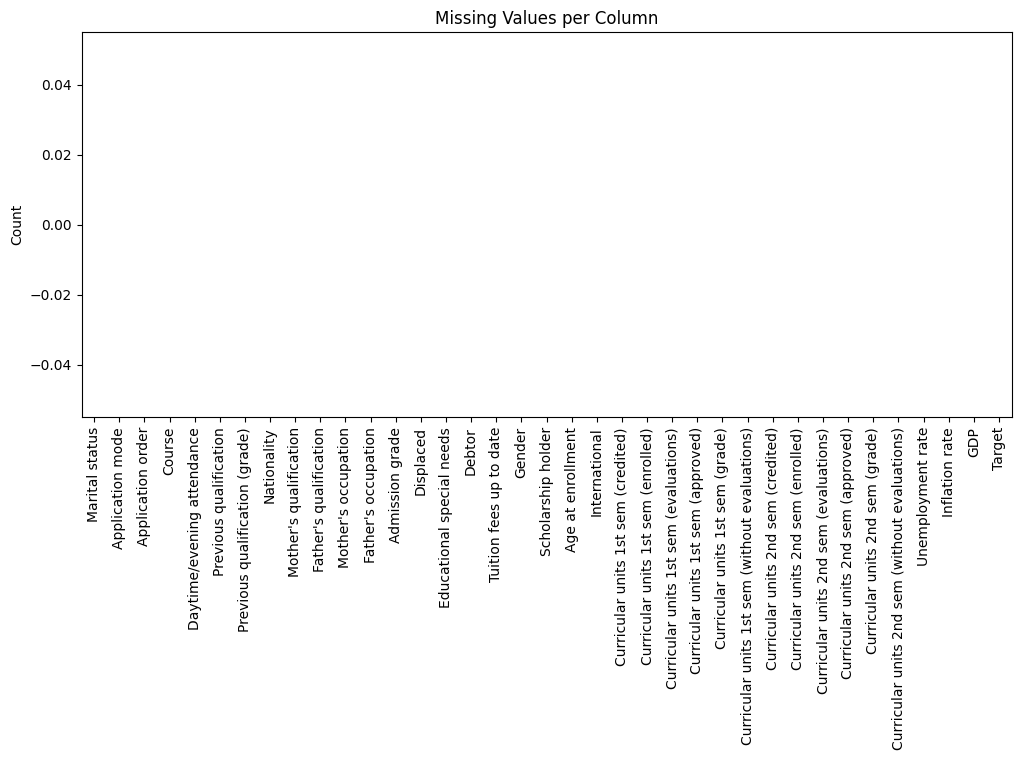

In [7]:
#Visualize Missingness

missing_count.plot(kind='bar', figsize=(12,5))
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [8]:
#Check Duplicate Rows
print("\n===== DUPLICATES =====")
print("Duplicate rows:", df.duplicated().sum())


===== DUPLICATES =====
Duplicate rows: 0


In [9]:
#Show Numerical Summary

print("\n===== NUMERICAL SUMMARY =====")
print(df.describe())


===== NUMERICAL SUMMARY =====
       Application order  Daytime/evening attendance  \
count        4424.000000                 4424.000000   
mean            1.727848                    0.890823   
std             1.313793                    0.311897   
min             0.000000                    0.000000   
25%             1.000000                    1.000000   
50%             1.000000                    1.000000   
75%             2.000000                    1.000000   
max             9.000000                    1.000000   

       Previous qualification (grade)  Admission grade  Age at enrollment  \
count                     4424.000000      4424.000000        4424.000000   
mean                       132.613314       126.978119          23.265145   
std                         13.188332        14.482001           7.587816   
min                         95.000000        95.000000          17.000000   
25%                        125.000000       117.900000          19.000000   
50

In [10]:
#Show Categorical Summary

print("\n===== CATEGORICAL SUMMARY =====")
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


===== CATEGORICAL SUMMARY =====

--- Marital status ---
Marital status
Single               3919
Married               379
Divorced               91
Facto Union            25
Legally Separated       6
Widower                 4
Name: count, dtype: int64

--- Application mode ---
Application mode
1st Phase — General Contingent                         1708
2nd Phase — General Contingent                          872
Over 23 Years Old                                       785
Change of Course                                        312
Technological Specialization Diploma Holders            213
Holders of Other Higher Courses                         139
3rd Phase — General Contingent                          124
Transfer                                                 77
Change of Institution/Course                             59
1st Phase — Special Contingent (Madeira Island)          38
Short Cycle Diploma Holders                              35
International Student (Bachelor)           

C:\Users\63929\AppData\Local\Temp\ipykernel_23984\3818691932.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns



===== TARGET DISTRIBUTION =====
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


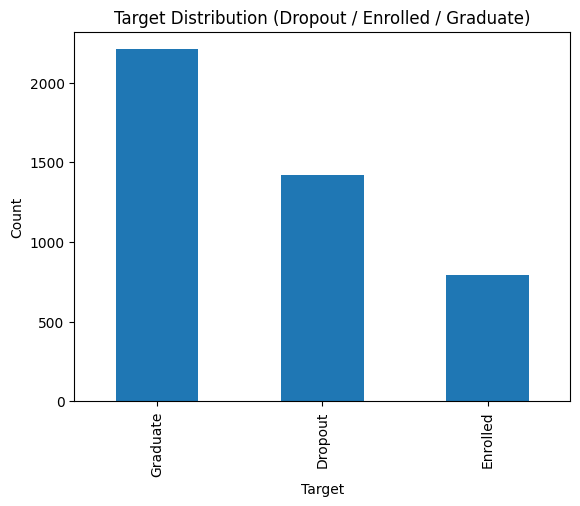

In [11]:
#Target Distribution

if "Target" in df.columns:
    print("\n===== TARGET DISTRIBUTION =====")
    print(df["Target"].value_counts())

    df["Target"].value_counts().plot(kind='bar')
    plt.title("Target Distribution (Dropout / Enrolled / Graduate)")
    plt.ylabel("Count")
    plt.show()

In [12]:
#Check Unique Values

print("\n===== UNIQUE VALUES PER COLUMN =====")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


===== UNIQUE VALUES PER COLUMN =====
Marital status: 6
Application mode: 18
Application order: 8
Course: 17
Daytime/evening attendance: 2
Previous qualification: 17
Previous qualification (grade): 101
Nationality: 21
Mother's qualification: 29
Father's qualification: 34
Mother's occupation: 32
Father's occupation: 46
Admission grade: 620
Displaced: 2
Educational special needs: 2
Debtor: 2
Tuition fees up to date: 2
Gender: 2
Scholarship holder: 2
Age at enrollment: 46
International: 2
Curricular units 1st sem (credited): 21
Curricular units 1st sem (enrolled): 23
Curricular units 1st sem (evaluations): 35
Curricular units 1st sem (approved): 23
Curricular units 1st sem (grade): 805
Curricular units 1st sem (without evaluations): 11
Curricular units 2nd sem (credited): 19
Curricular units 2nd sem (enrolled): 22
Curricular units 2nd sem (evaluations): 30
Curricular units 2nd sem (approved): 20
Curricular units 2nd sem (grade): 786
Curricular units 2nd sem (without evaluations): 10
Unemp

In [13]:
#Data Quality Check

print("\n===== DATA QUALITY CHECK =====")

# Check if any column is fully empty
empty_cols = df.columns[df.isnull().all()]
print("Fully empty columns:", list(empty_cols))

# Check columns with too many missing values (>30%)
high_missing = (df.isnull().sum() / len(df)) * 100
print("\nColumns with >30% missing:")
print(high_missing[high_missing > 30])


===== DATA QUALITY CHECK =====
Fully empty columns: []

Columns with >30% missing:
Series([], dtype: float64)


In [14]:
#Handling Missing Values

df.fillna("Unknown", inplace=True)

print("\n===== AFTER CLEANING =====")
print(df.isnull().sum())


===== AFTER CLEANING =====
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nationality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                  

In [18]:
#Save Clean Data
df.to_csv("cleaned_data.csv", index=False)
print("\nCleaned dataset saved as cleaned_data.csv")


Cleaned dataset saved as cleaned_data.csv
